# Import Libraries

In [12]:
import pandas as pd
import numpy as np
import pickle
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Load Dataset

In [13]:
train_df = pd.read_csv('../data/data_train_master.csv')
train_df.head(5)

,clean_text,emotion
0,thanks mate! i havent given that idea much tho...,Joy
1,feel you pain. stay strong,Sadness
2,i constantly feel like i'm my husband's best f...,Sadness
3,"been together 6 years, and i think she's the b...",Love
4,"amen! however, see my post about the problem w...",Sadness


# Training

## Data Splitting

In [14]:
X_train_text = train_df['clean_text'].astype(str)
y_train_text = train_df['emotion']

## Label Encoding

Because Bi-LSTM works with numerical computations, the target labels need to be encoded into numerical representations before the training process.

In [15]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_text)

Then, the numerical labels are transformed into a multiclass categorical format using One-Hot Encoding to represent the 6 emotion classes.

In [16]:
y_train_categorical = to_categorical(y_train_encoded)
num_classes = y_train_categorical.shape[1]

## Tokenization & Padding

In [17]:
max_vocab = 20000
max_length = 60

In [18]:
# Building a Vocabulary based on training dataset
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

In [19]:
# Turn text into Sequence
X_train_seq = tokenizer.texts_to_sequences(X_train_text)

# Standardize the length of the input sequence.
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post') 

## Modelling

In [20]:
# Initialize
model = Sequential([
    # Layer 1: Changing Numerical Token into Vector Embedding
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_length),
    
    # Layer 2: First Bi-LSTM Layer, Reading the Context Sequence in Both Directions
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3), # Dropout layer to prevent overfitting
    
    # Layer 3: Deeper Understanding of the Context
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    
    # Layer 4: Dense Neural Network to summarize before last classification
    Dense(64, activation='relu'),
    
    # Output Layer: Softmax activation for multiclass emotion classification
    Dense(num_classes, activation='softmax') 
])

In [21]:
# Loss Function, Optimizer, Evaluation Metric
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 60, 128)           2560000   
                                                                 
 bidirectional_2 (Bidirectio  (None, 60, 128)          98816     
 nal)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 60, 128)           0         
                                                                 
 bidirectional_3 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 64)               

Slight Overfitting after the third epoch. Possible Improvement:
- Early stopping epoch before model does overfit
- Increase the dropout rate
- Use a Pre-Trained Embeddings

## Training the Model

In [22]:
history = model.fit(
    X_train_pad, y_train_categorical, 
    epochs=5,              # 5 Training Iterations
    batch_size=64,         # Processing 64 sentences at a time
    validation_split=0.1   # 10% Validation Split
)

Epoch 1/5
431/431 [==============================] - 35s 74ms/step - loss: 1.2647 - accuracy: 0.5140 - val_loss: 0.9719 - val_accuracy: 0.6635
Epoch 2/5
431/431 [==============================] - 37s 87ms/step - loss: 0.8191 - accuracy: 0.7179 - val_loss: 0.8838 - val_accuracy: 0.7027
Epoch 3/5
431/431 [==============================] - 36s 84ms/step - loss: 0.6200 - accuracy: 0.8038 - val_loss: 0.9139 - val_accuracy: 0.7034
Epoch 4/5
431/431 [==============================] - 36s 84ms/step - loss: 0.5078 - accuracy: 0.8398 - val_loss: 0.9824 - val_accuracy: 0.6975
Epoch 5/5
431/431 [==============================] - 35s 81ms/step - loss: 0.4454 - accuracy: 0.8531 - val_loss: 1.0389 - val_accuracy: 0.6923


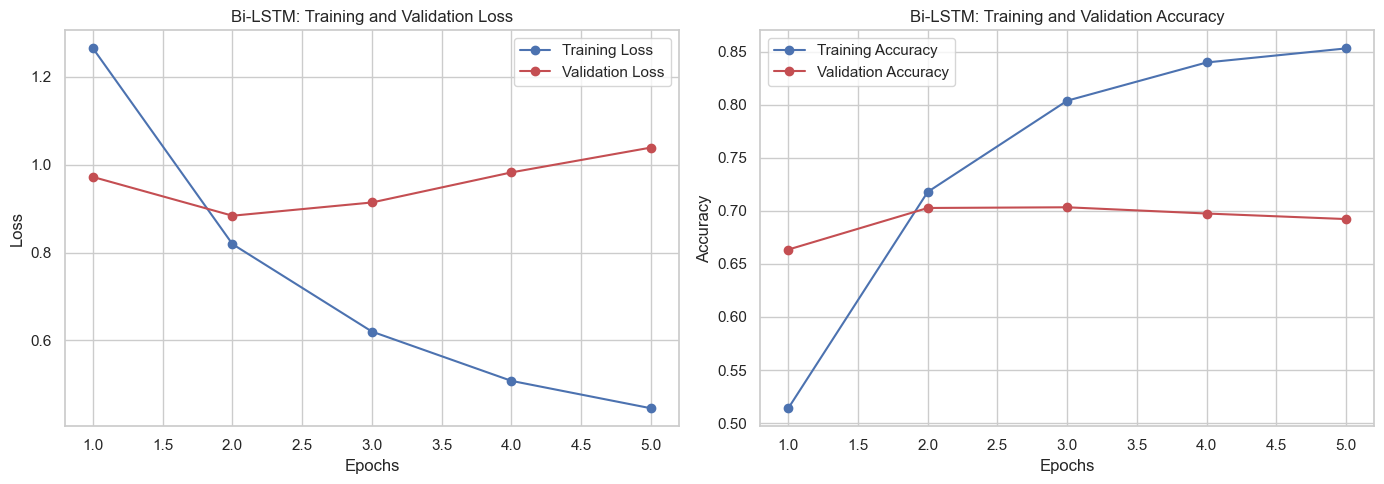

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Extract data from history keras
acc = history.history['accuracy']
val_acc = history.history['val_accuracy'] 
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, loss, 'bo-', label='Training Loss')
ax1.plot(epochs, val_loss, 'ro-', label='Validation Loss')
ax1.set_title('Bi-LSTM: Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, acc, 'bo-', label='Training Accuracy')
ax2.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax2.set_title('Bi-LSTM: Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# Dump Model

In [24]:
model.save('../models/bilstm/bilstm_model.keras')

with open('../models/bilstm/tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('../models/bilstm/label_encoder.pkl', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)